In [1]:
!pip -qq install fastmri

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.6 MB/s eta 0:00:00


In [4]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.5 MB/s eta 0:00:00


In [16]:
import pydicom
import numpy as np
from matplotlib import pyplot as plt

In [17]:
file_path = '/content/I0000418_anon.dcm'

In [18]:
dcm_data = pydicom.dcmread(file_path)

In [19]:
slice_image = dcm_data.pixel_array

In [9]:
# print(dcm_data)

In [12]:
print(f"Data Type: {slice_image.dtype}")
print(f"Reconstructed Image shape (Height, Width): {slice_image.shape}")

Data Type: int16
Reconstructed Image shape (Height, Width): (256, 256)


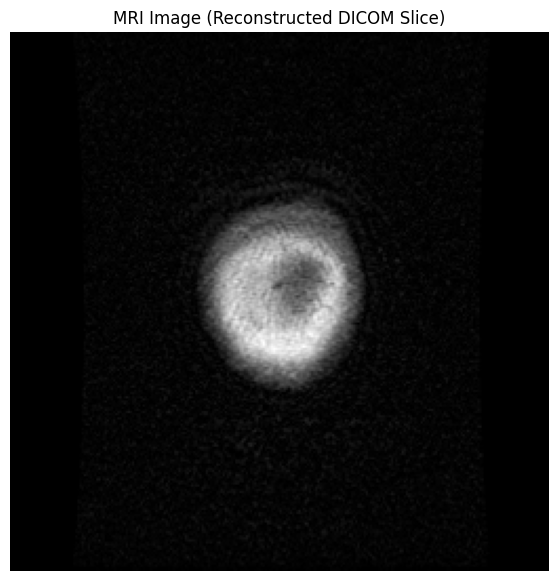

In [20]:
plt.figure(figsize=(7, 7))
plt.imshow(slice_image, cmap='gray')
plt.title("MRI Image (Reconstructed DICOM Slice)")
plt.axis('off')
plt.show()

MRI 3D Recon

In [21]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_opening
from skimage.measure import label, regionprops, marching_cubes

In [22]:
file_path = '/content/I0000418_anon.dcm'
dcm_data = pydicom.dcmread(file_path)

In [38]:
pixel_spacing = dcm_data.get("PixelSpacing", [1.0, 1.0])
slice_thickness = dcm_data.get("SliceThickness", 5.0)
voxel_size = np.array([pixel_spacing[0], pixel_spacing[1], slice_thickness])

In [39]:
single_slice = dcm_data.pixel_array.astype(np.uint16)
max_value = float(np.max(single_slice))

In [40]:
num_slices = 40
DataImage = np.stack([single_slice] * num_slices, axis=-1)  # Dimensions: (H, W, Slices)
print(f"Data volume built with shape: {DataImage.shape}")

Data volume built with shape: (256, 256, 40)


In [41]:
SegmentedBrainMRI = DataImage.copy()
Threshold_lowerBound = 40
Threshold_upperBound = 100

In [42]:
# Zero out background/skull noise
SegmentedBrainMRI[SegmentedBrainMRI >= Threshold_upperBound] = 0
SegmentedBrainMRI[SegmentedBrainMRI <= Threshold_lowerBound] = 0

In [44]:
height_limit = int(SegmentedBrainMRI.shape[0] * 0.85)
SegmentedBrainMRI[height_limit:, :, :] = 0

black_white = SegmentedBrainMRI > 0

In [45]:
structuring_element = np.ones((7, 7, 3), dtype=bool)
black_white_cleaned = binary_opening(black_white, structure=structuring_element)

In [46]:
label_matrix = label(black_white_cleaned)
regions = regionprops(label_matrix)

In [48]:
if len(regions) > 0:
    biggest_region = max(regions, key=lambda r: r.area)
    SegmentedBrainMRI[label_matrix != biggest_region.label] = 0
else:
    print("Warning: No regions detected.")

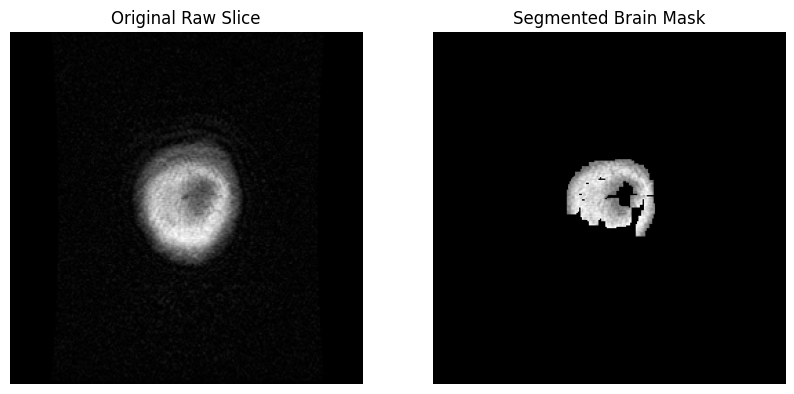

In [49]:
mid_idx = num_slices // 2
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(single_slice, cmap='gray')
ax[0].set_title("Original Raw Slice")
ax[0].axis('off')

ax[1].imshow(SegmentedBrainMRI[:, :, mid_idx], cmap='gray')
ax[1].set_title("Segmented Brain Mask")
ax[1].axis('off')
plt.show()

In [50]:
brain_intensities = SegmentedBrainMRI[SegmentedBrainMRI > 0]
if len(brain_intensities) > 0:
    level = np.median(brain_intensities)
else:
    level = (Threshold_lowerBound + Threshold_upperBound) / 2

mriPartition = np.zeros_like(SegmentedBrainMRI, dtype=np.uint8)
mriPartition[(SegmentedBrainMRI > 0) & (SegmentedBrainMRI < level)] = 2  # Gray Matter
mriPartition[SegmentedBrainMRI >= level] = 3

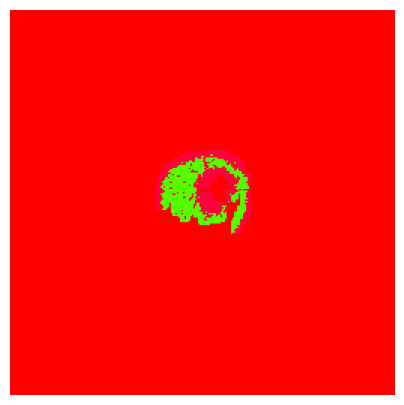

In [52]:
plt.figure(figsize=(5, 5))
plt.imshow(mriPartition[:, :, mid_idx], cmap='prism')
plt.axis('off')
plt.show()

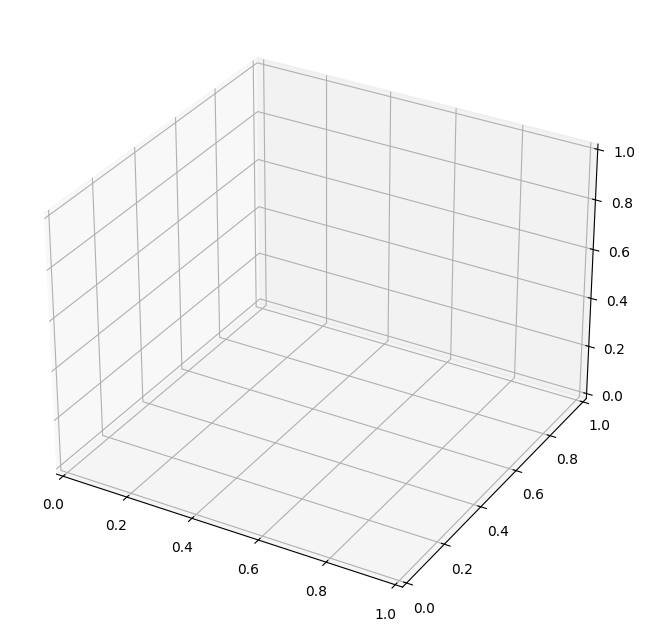

In [53]:
Ds = mriPartition[::2, ::2, :]
Ds = np.transpose(Ds, (2, 1, 0)) # Reshape to Z, Y, X layout

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

In [55]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

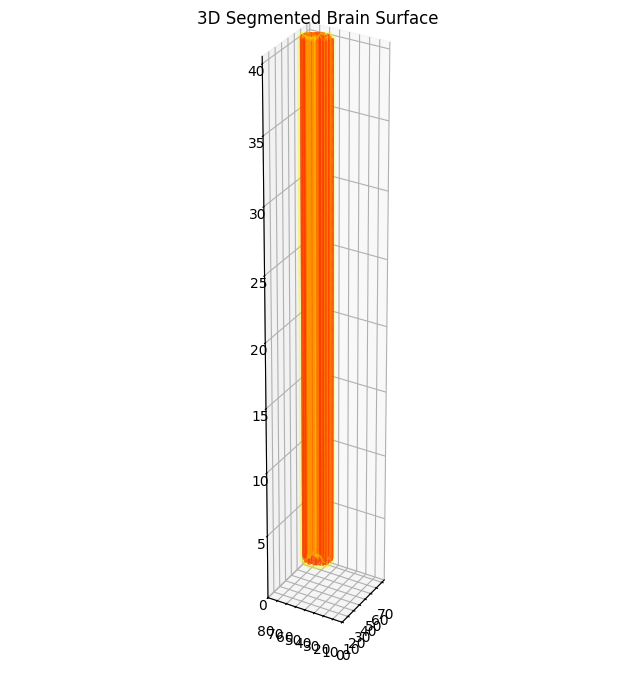

In [60]:
padded_Ds = np.zeros((Ds.shape[0], Ds.shape[1], Ds.shape[2] + 2), dtype=Ds.dtype)
padded_Ds[:, :, 1:-1] = Ds

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

max_coords = [10, 10, 10]

try:
    verts_g, faces_g, _, _ = marching_cubes(padded_Ds, level=1.5)
    mesh_g = Poly3DCollection(verts_g[faces_g], alpha=0.15, facecolor='yellow', edgecolor='none')
    ax.add_collection3d(mesh_g)
    max_coords = np.max(verts_g, axis=0)
except ValueError as e:
    print("Gray matter surface could not be calculated:", e)

try:
    verts_w, faces_w, _, _ = marching_cubes(padded_Ds, level=2.5)
    mesh_w = Poly3DCollection(verts_w[faces_w], alpha=0.70, facecolor='red', edgecolor='none')
    ax.add_collection3d(mesh_w)
    if np.max(verts_w, axis=0)[0] > max_coords[0]:
        max_coords = np.max(verts_w, axis=0)
except ValueError as e:
    print("White matter surface could not be calculated:", e)

ax.set_xlim(0, max_coords[0])
ax.set_ylim(0, max_coords[1])
ax.set_zlim(0, max_coords[2])

voxel_size2 = voxel_size * np.array([2, 2, 4])
ax.set_box_aspect((voxel_size2[0], voxel_size2[1], voxel_size2[2]))

ax.view_init(elev=30, azim=210)
ax.axis('on')
plt.title("3D Segmented Brain Surface")
plt.show()